### Descriptive Analysis


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re as r

In [4]:
path = r'C:\Users\ACER\Documents\datathon-2026-round-1\Datathon_Contest_UITUT\Data' 

# 2. Lấy danh sách tất cả các file trong thư mục
files = [f for f in os.listdir(path) if f.endswith('.csv')]

for file in files:
    # Tách tên file và phần mở rộng (vd: 'data.csv' -> 'data')
    file_name = os.path.splitext(file)[0]
    
    # Tạo đường dẫn đầy đủ
    full_path = os.path.join(path, file)
    
    # Đọc file và gán vào biến có tên df_tên_file
    # globals() giúp tạo biến động trong môi trường hiện tại
    globals()[f"df_{file_name}"] = pd.read_csv(full_path)
    
    print(f"Đã load xong: df_{file_name}")

Đã load xong: df_customers
Đã load xong: df_geography
Đã load xong: df_inventory
Đã load xong: df_orders


C:\Users\ACER\AppData\Local\Temp\ipykernel_17432\3359505436.py:15: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  globals()[f"df_{file_name}"] = pd.read_csv(full_path)


Đã load xong: df_order_items
Đã load xong: df_payments
Đã load xong: df_products
Đã load xong: df_promotions
Đã load xong: df_returns
Đã load xong: df_reviews
Đã load xong: df_sales
Đã load xong: df_sample_submission
Đã load xong: df_shipments
Đã load xong: df_web_traffic


In [5]:
# Giả sử files là danh sách tên file ông đã lấy ở bước trước
count = 0
for file in files:
    file_name = os.path.splitext(file)[0]
    var_name = f"df_{file_name}"
    count = count + 1
    # Kiểm tra xem biến đó có tồn tại trong globals không để tránh lỗi
    if var_name in globals():
        df = globals()[var_name]
        print(f"--- Bảng: {var_name} ---")
        print(f"Danh sách cột: {list(df.columns)}")
        print(f"Số lượng cột: {len(df.columns)}")
        print("-" * 30)
print("SỐ LƯỢNG BẢNG: ", count)

--- Bảng: df_customers ---
Danh sách cột: ['customer_id', 'zip', 'city', 'signup_date', 'gender', 'age_group', 'acquisition_channel']
Số lượng cột: 7
------------------------------
--- Bảng: df_geography ---
Danh sách cột: ['zip', 'city', 'region', 'district']
Số lượng cột: 4
------------------------------
--- Bảng: df_inventory ---
Danh sách cột: ['snapshot_date', 'product_id', 'stock_on_hand', 'units_received', 'units_sold', 'stockout_days', 'days_of_supply', 'fill_rate', 'stockout_flag', 'overstock_flag', 'reorder_flag', 'sell_through_rate', 'product_name', 'category', 'segment', 'year', 'month']
Số lượng cột: 17
------------------------------
--- Bảng: df_orders ---
Danh sách cột: ['order_id', 'order_date', 'customer_id', 'zip', 'order_status', 'payment_method', 'device_type', 'order_source']
Số lượng cột: 8
------------------------------
--- Bảng: df_order_items ---
Danh sách cột: ['order_id', 'product_id', 'quantity', 'unit_price', 'discount_amount', 'promo_id', 'promo_id_2']
Số 

In [6]:
import pandas as pd

def create_data_health_report():
    # 1. Lấy danh sách các DataFrame đang có trong bộ nhớ (biến bắt đầu bằng df_)
    all_dfs = {k: v for k, v in globals().items() if k.startswith('df_') and isinstance(v, pd.DataFrame)}
    
    # Loại bỏ chính cái bảng report nếu nó đã tồn tại để tránh đệ quy
    all_dfs = {k: v for k, v in all_dfs.items() if k != 'df_final_report'}

    report_data = []

    for name, df in all_dfs.items():
        # Tính toán các thông số cơ bản
        total_rows = len(df)
        total_cols = len(df.columns)
        null_count = df.isnull().sum().sum()
        duplicate_count = df.duplicated().sum()

        # Tính % dữ liệu bị thiếu
        total_cells = total_rows * total_cols
        missing_rate = (null_count / total_cells) * 100 if total_cells > 0 else 0

        # Xử lý Memory Usage cho dễ đọc (đổi sang MB nếu > 1024 KB)
        mem_bytes = df.memory_usage(deep=True).sum()
        if mem_bytes < 1024 * 1024:
            mem_display = f"{mem_bytes / 1024:.2f} KB"
        else:
            mem_display = f"{mem_bytes / (1024 * 1024):.2f} MB"

        # Lưu vào list
        report_data.append({
            'Table Name': name,
            'Total Rows': total_rows,
            'Total Cols': total_cols,
            'Total Null/NaN': null_count,
            'Duplicates': duplicate_count,
            'Missing Rate (%)': round(missing_rate, 2),
            'Memory Usage': mem_display
        })

    # 2. Tạo DataFrame từ list kết quả và sắp xếp theo bảng có nhiều Null nhất hoặc nặng nhất
    health_report = pd.DataFrame(report_data)
    
    if not health_report.empty:
        health_report = health_report.sort_values(by='Total Null/NaN', ascending=False)
        
    return health_report

# 3. Chạy và hiển thị bảng báo cáo
df_final_report = create_data_health_report()

print("\n🚀 --- BẢNG TỔNG HỢP CHẤT LƯỢNG DỮ LIỆU --- 🚀")
# Kiểm tra nếu máy có cài thư viện tabulate để dùng to_markdown
try:
    print(df_final_report.to_markdown(index=False))
except ImportError:
    print(df_final_report.to_string(index=False))



🚀 --- BẢNG TỔNG HỢP CHẤT LƯỢNG DỮ LIỆU --- 🚀
| Table Name           |   Total Rows |   Total Cols |   Total Null/NaN |   Duplicates |   Missing Rate (%) | Memory Usage   |
|:---------------------|-------------:|-------------:|-----------------:|-------------:|-------------------:|:---------------|
| df_order_items       |       714669 |            7 |          1152816 |            0 |              23.04 | 78.00 MB       |
| df_promotions        |           50 |           10 |               40 |            0 |               8    | 20.68 KB       |
| df_geography         |        39948 |            4 |                0 |            0 |               0    | 6.86 MB        |
| df_inventory         |        60247 |           17 |                0 |            0 |               0    | 19.69 MB       |
| df_orders            |       646945 |            8 |                0 |            0 |               0    | 194.24 MB      |
| df_customers         |       121930 |            7 |           

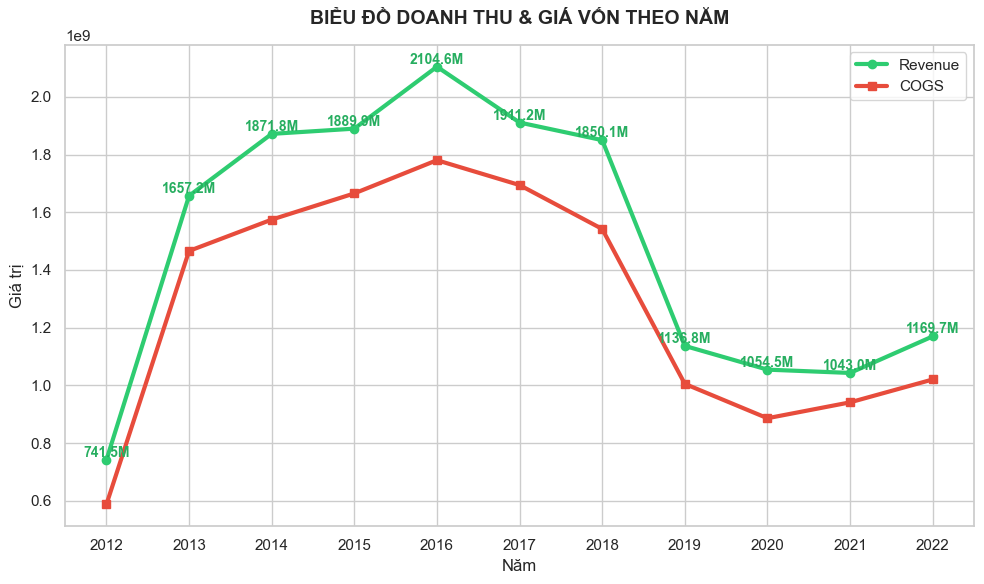

In [7]:
df_sales['Date'] = pd.to_datetime(df_sales['Date'])

# Tạo cột Year và tính tổng theo năm
df_yearly = df_sales.groupby(df_sales['Date'].dt.year).agg({
    'Revenue': 'sum',
    'COGS': 'sum'
}).reset_index()

# 2. Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Vẽ đường Revenue & COGS theo Năm
plt.plot(df_yearly['Date'], df_yearly['Revenue'], marker='o', label='Revenue', color='#2ecc71', linewidth=3)
plt.plot(df_yearly['Date'], df_yearly['COGS'], marker='s', label='COGS', color='#e74c3c', linewidth=3)

# 3. Trang trí
plt.title('BIỂU ĐỒ DOANH THU & GIÁ VỐN THEO NĂM', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Giá trị', fontsize=12)

# Hiển thị số liệu (Data Labels) theo đơn vị tỷ (hoặc triệu tùy ông)
for i in range(len(df_yearly)):
    plt.text(df_yearly['Date'][i], df_yearly['Revenue'][i], f"{df_yearly['Revenue'][i]/1e6:.1f}M", 
             va='bottom', ha='center', fontsize=10, color='#27ae60', fontweight='bold')

# Fix trục X chỉ hiển thị số năm nguyên (2012, 2013...)
plt.xticks(df_yearly['Date'].astype(int)) 

plt.legend()
plt.tight_layout()
plt.show()

TOP 8 SEGMENTS CÓ TỶ SUẤT LỢI NHUẬN GỘP CAO NHẤT


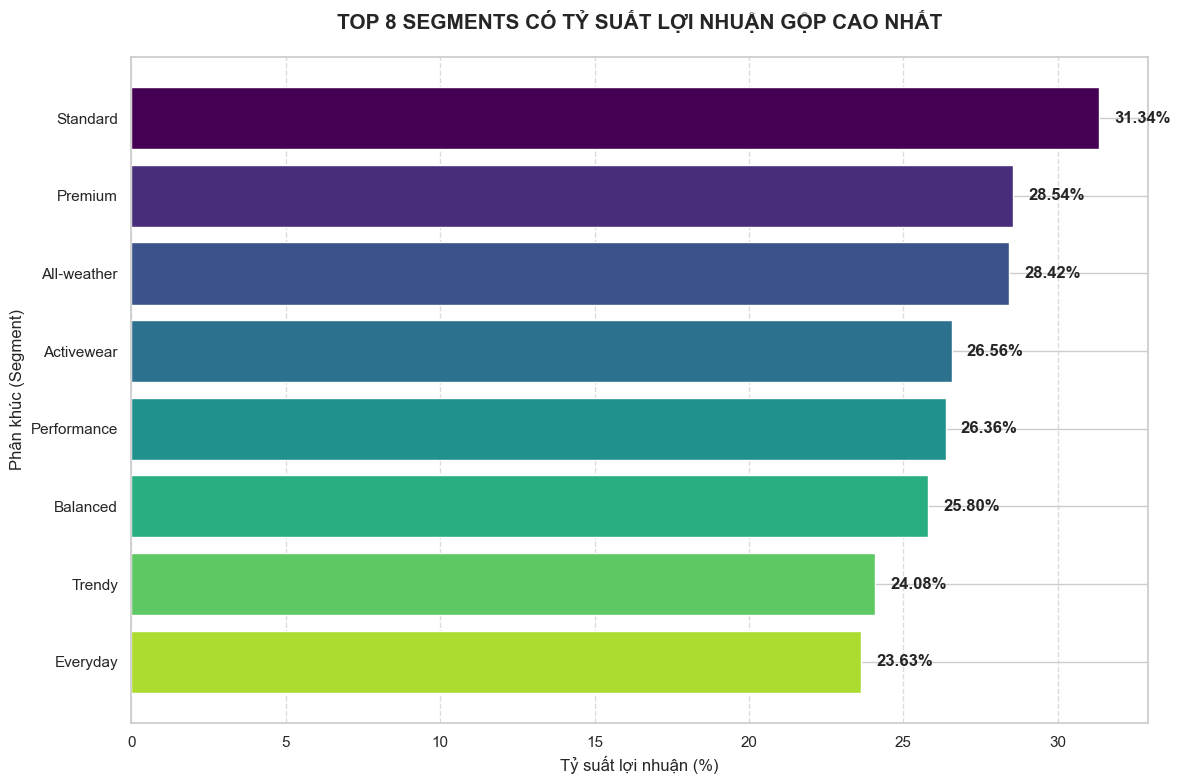

In [8]:

print("TOP 8 SEGMENTS CÓ TỶ SUẤT LỢI NHUẬN GỘP CAO NHẤT")
# 1. Tính Tỷ suất lợi nhuận gộp cho từng sản phẩm
# Công thức: (Price - COGS) / Price
df_products['gross_margin'] = (df_products['price'] - df_products['cogs']) / df_products['price']

# 2. Gom nhóm theo Segment và tính trung bình (Mean)
# Sau đó sắp xếp giảm dần và lấy 8 thằng đầu bảng
df_top8_segment = df_products.groupby('segment')['gross_margin'].mean().sort_values(ascending=False).head(8).reset_index()

# Chuyển về % cho dễ đọc
df_top8_segment['margin_pct'] = df_top8_segment['gross_margin'] * 100

# 3. Vẽ biểu đồ cột ngang (Horizontal Bar Chart)
plt.figure(figsize=(12, 8))
colors = plt.cm.viridis(range(0, 256, 32)) # Tạo bảng màu cho đẹp

bars = plt.barh(df_top8_segment['segment'], df_top8_segment['margin_pct'], color=colors)

# 4. Trang trí biểu đồ
plt.title('TOP 8 SEGMENTS CÓ TỶ SUẤT LỢI NHUẬN GỘP CAO NHẤT', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Tỷ suất lợi nhuận (%)', fontsize=12)
plt.ylabel('Phân khúc (Segment)', fontsize=12)
plt.gca().invert_yaxis()  # Đảo ngược trục Y để thằng cao nhất nằm trên cùng
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Ghi số liệu % trực tiếp lên đầu cột
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{width:.2f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\ACER\AppData\Local\Temp\ipykernel_17432\3692902845.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  chart = sns.barplot(
C:\Users\ACER\AppData\Local\Temp\ipykernel_17432\3692902845.py:34: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ACER\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


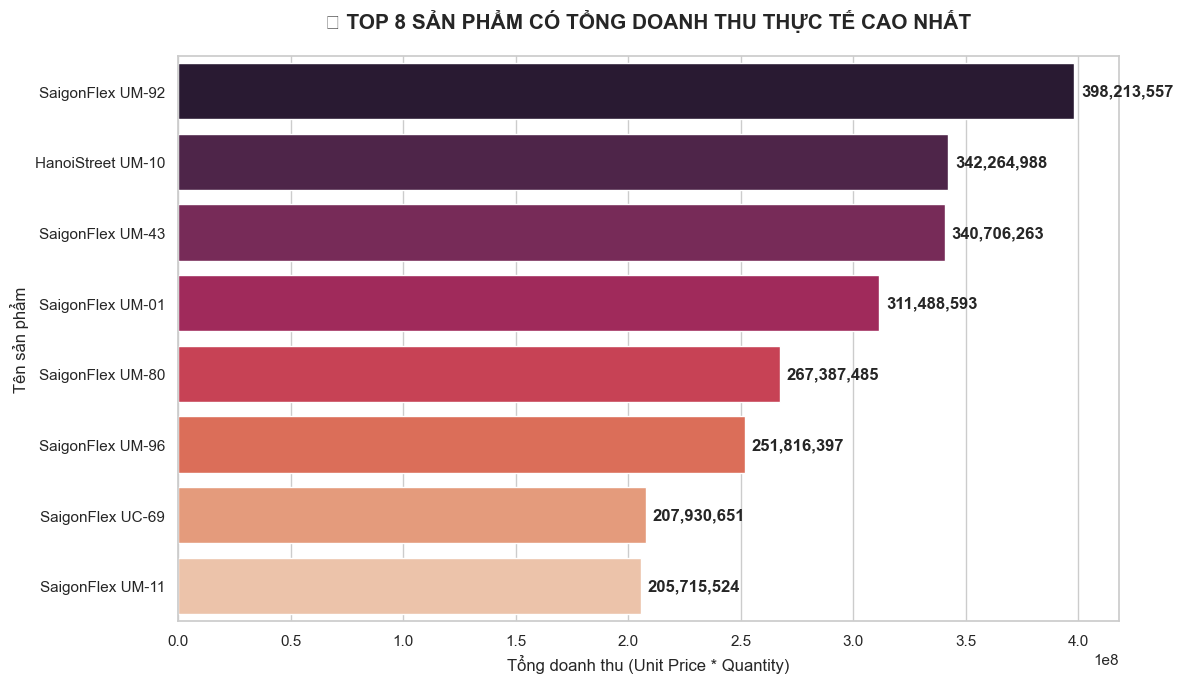

In [9]:
df_master = df_order_items.merge(df_orders[['order_id', 'order_date']], on='order_id', how='left')

# 2. Nối tiếp với df_products để lấy tên sản phẩm (product_name)
df_master = df_master.merge(df_products[['product_id', 'product_name']], on='product_id', how='left')

# 3. Tính Doanh thu thực tế theo từng dòng
# Công thức: unit_price (giá bán thực tế) * quantity (số lượng)
df_master['actual_revenue'] = df_master['unit_price'] * df_master['quantity']

# 4. Aggregate: Tính tổng doanh thu theo tên sản phẩm và lấy Top 8
df_top8_revenue = df_master.groupby('product_name')['actual_revenue'].sum().sort_values(ascending=False).head(8).reset_index()

# 5. Vẽ biểu đồ cột ngang
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Vẽ biểu đồ với tone màu 'rocket' nhìn cho nó rực cháy
chart = sns.barplot(
    data=df_top8_revenue, 
    x='actual_revenue', 
    y='product_name', 
    palette='rocket'
)

# 6. Trang trí
plt.title('📊 TOP 8 SẢN PHẨM CÓ TỔNG DOANH THU THỰC TẾ CAO NHẤT', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Tổng doanh thu (Unit Price * Quantity)', fontsize=12)
plt.ylabel('Tên sản phẩm', fontsize=12)

# Thêm nhãn số tiền lên đầu cột, định dạng có dấu phẩy ngăn cách nghìn
for container in chart.containers:
    chart.bar_label(container, fmt='{:,.0f}', padding=5, fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\ACER\AppData\Local\Temp\ipykernel_17432\2893291452.py:43: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ACER\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


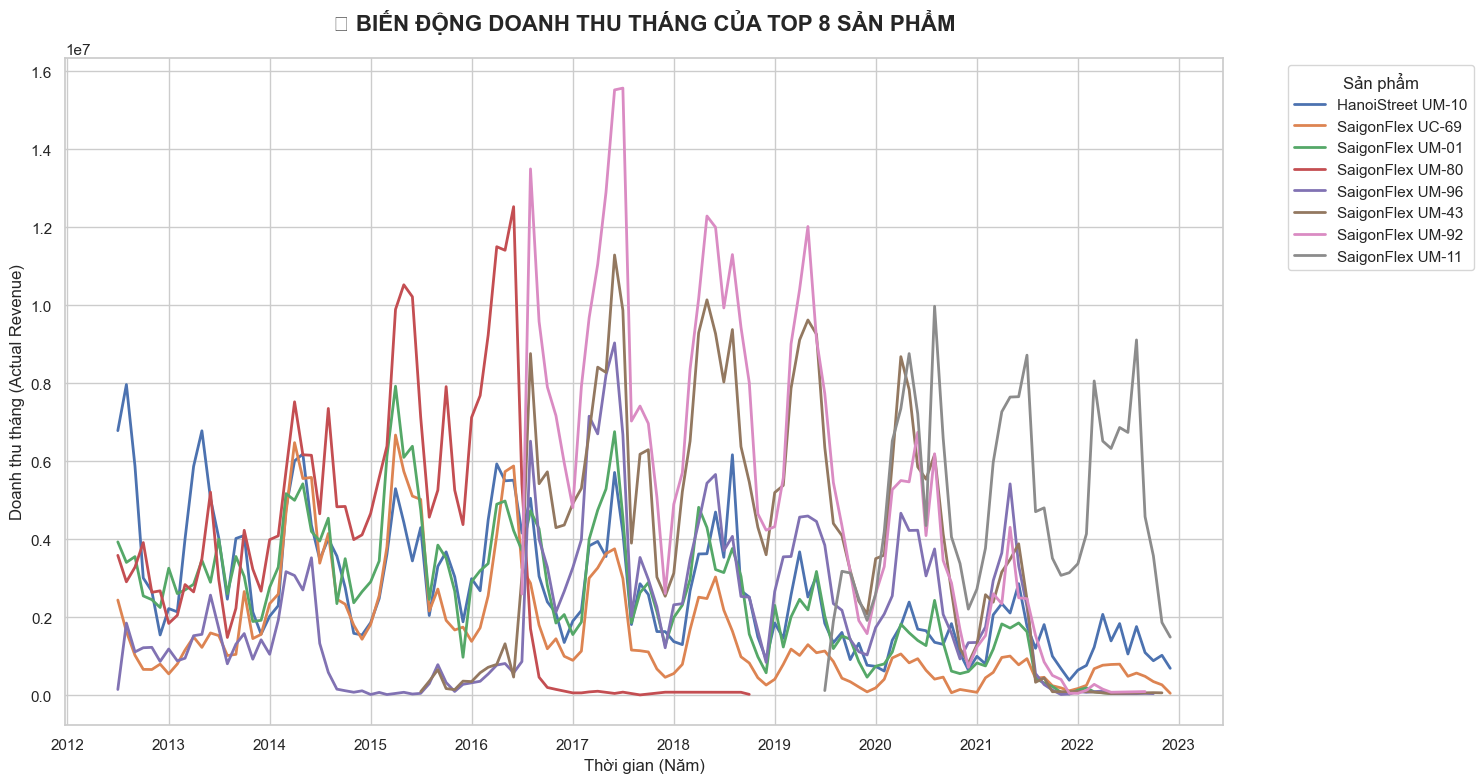

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# 1. Chuẩn bị dữ liệu
df_master['order_date'] = pd.to_datetime(df_master['order_date'])
df_master['actual_revenue'] = df_master['unit_price'] * df_master['quantity']

# 2. Lấy danh sách Top 8 (vẫn dựa trên tổng doanh thu lịch sử)
top_8_names = df_master.groupby('product_name')['actual_revenue'].sum().sort_values(ascending=False).head(8).index

# 3. Lọc lấy 8 ông nội này
df_top8_ts = df_master[df_master['product_name'].isin(top_8_names)].copy()

# 4. Gom nhóm theo THÁNG (Month)
# Dùng Grouper để dữ liệu liên tục theo dòng thời gian
df_plot_ts = df_top8_ts.groupby([pd.Grouper(key='order_date', freq='MS'), 'product_name'])['actual_revenue'].sum().reset_index()

# 5. Vẽ biểu đồ
plt.figure(figsize=(15, 8))
sns.set_theme(style="whitegrid")

ax = sns.lineplot(
    data=df_plot_ts, 
    x='order_date', 
    y='actual_revenue', 
    hue='product_name', 
    marker=None, # Bỏ marker đi cho đỡ rối vì dữ liệu theo tháng rất dày
    linewidth=2
)

# 6. CHIÊU THỨC: Chỉ hiển thị NĂM trên trục X
ax.xaxis.set_major_locator(mdates.YearLocator()) # Chỉ đánh mốc tại các năm
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y')) # Định dạng hiển thị là số Năm (2012, 2013...)

# 7. Trang trí
plt.title('CHU KỲ SỐNG SẢN PHẨM - BIẾN ĐỘNG DOANH THU THÁNG CỦA TOP 8 SẢN PHẨM (Đơn vịr)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Thời gian (Năm)', fontsize=12)
plt.ylabel('Doanh thu tháng (Actual Revenue)', fontsize=12)

plt.legend(title='Sản phẩm', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [13]:
# 1. Tạo thêm cột Năm để dễ pivot
df_top8_ts['year'] = df_top8_ts['order_date'].dt.year

# 2. Tạo bảng Pivot: Sản phẩm làm index, Năm làm cột, Doanh thu làm giá trị
df_pivot_table = df_top8_ts.pivot_table(
    index='product_name', 
    columns='year', 
    values='actual_revenue', 
    aggfunc='sum',
    fill_value=0  # Nếu năm đó sản phẩm không bán được thì để là 0
)

# 3. Tính thêm cột "Tổng cộng" để xem ông nào là 'vua doanh thu' thực sự
df_pivot_table['Total_All_Years'] = df_pivot_table.sum(axis=1)

# 4. Sắp xếp lại theo tổng doanh thu từ cao xuống thấp
df_pivot_table = df_pivot_table.sort_values(by='Total_All_Years', ascending=False)

# 5. Format số liệu cho dễ nhìn (thêm dấu phẩy ngăn cách hàng nghìn)
pd.options.display.float_format = '{:,.0f}'.format

print("--- BẢNG THEO DÕI DOANH THU TOP 8 SẢN PHẨM QUA CÁC NĂM ---")
print(df_pivot_table.to_markdown())

--- BẢNG THEO DÕI DOANH THU TOP 8 SẢN PHẨM QUA CÁC NĂM ---
| product_name      |        2012 |        2013 |        2014 |        2015 |        2016 |             2017 |             2018 |        2019 |        2020 |        2021 |             2022 |   Total_All_Years |
|:------------------|------------:|------------:|------------:|------------:|------------:|-----------------:|-----------------:|------------:|------------:|------------:|-----------------:|------------------:|
| SaigonFlex UM-92  | 0           | 0           | 0           | 0           | 4.67332e+07 |      1.06596e+08 |      1.01039e+08 | 7.46972e+07 | 4.79634e+07 | 2.03844e+07 | 800111           |       3.98214e+08 |
| HanoiStreet UM-10 | 2.78695e+07 | 4.44193e+07 | 4.26634e+07 | 3.94201e+07 | 4.52595e+07 |      3.58544e+07 |      3.46608e+07 | 2.29934e+07 | 1.65572e+07 | 1.80728e+07 |      1.44946e+07 |       3.42265e+08 |
| SaigonFlex UM-43  | 0           | 0           | 0           | 1.80029e+06 | 3.58864e+07 |      

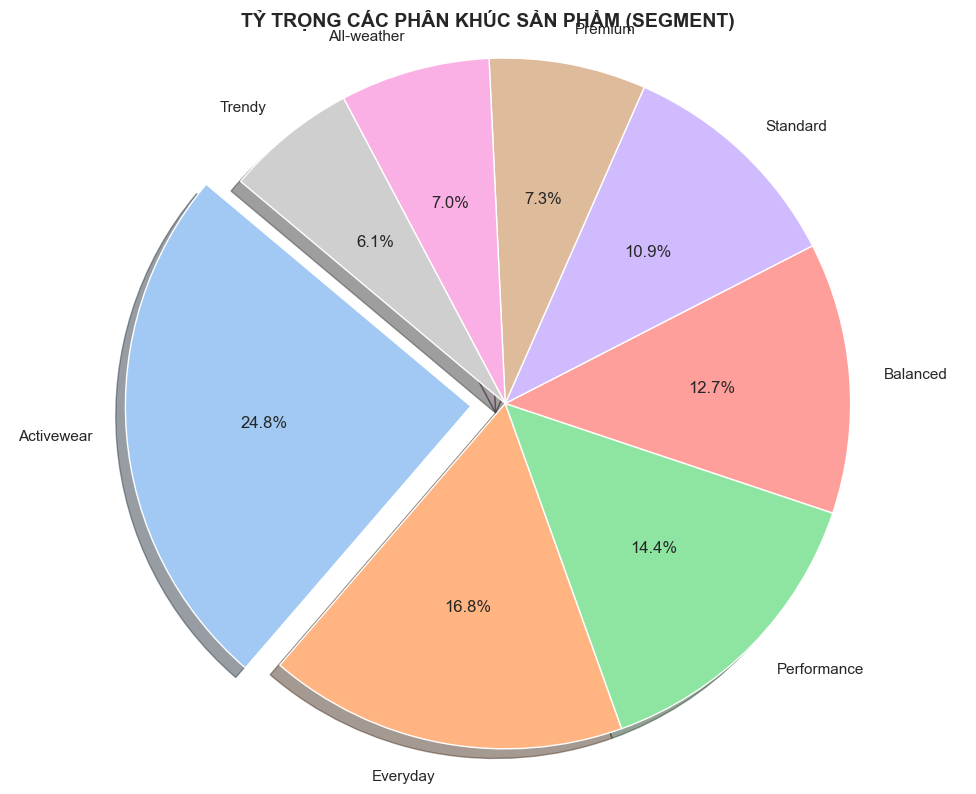

In [28]:

# 1. Thống kê số lượng sản phẩm theo từng Segment
segment_counts = df_products['segment'].value_counts()

# 2. Cấu hình biểu đồ
plt.figure(figsize=(10, 8))
colors = sns.color_palette('pastel')[0:len(segment_counts)] # Bộ màu pastel cho dịu mắt

# Tạo hiệu ứng "nổ" nhẹ cho miếng bánh lớn nhất
explode = [0.1 if i == 0 else 0 for i in range(len(segment_counts))]

# 3. Vẽ Pie Chart
plt.pie(
    segment_counts, 
    labels=segment_counts.index, 
    autopct='%1.1f%%',       # Hiển thị phần trăm có 1 chữ số thập phân
    startangle=140,          # Xoay góc bắt đầu cho đẹp
    colors=colors, 
    explode=explode,         # Tách miếng to nhất ra
    shadow=True              # Đổ bóng cho xịn
)

# 4. Trang trí
plt.title('TỶ TRỌNG CÁC PHÂN KHÚC SẢN PHẨM (SEGMENT)', fontsize=14, fontweight='bold')
plt.axis('equal')  # Đảm bảo hình tròn không bị méo thành hình bầu dục

plt.tight_layout()
plt.show()

In [31]:
# 1. Lấy danh sách các cột là Năm (loại bỏ cột Total_All_Years)
year_columns = [col for col in df_pivot_table.columns if col != 'Total_All_Years']

# 2. Đếm số lượng giá trị bằng 0 trên mỗi dòng (mỗi sản phẩm)
# axis=1 là đếm theo hàng ngang
df_pivot_table['zero_years_count'] = (df_pivot_table[year_columns] == 0).sum(axis=1)

# 3. Sắp xếp theo số năm bằng 0 giảm dần, nếu bằng nhau thì ông nào doanh thu thấp hơn đứng trước
df_top_zero = df_pivot_table.sort_values(
    by=['zero_years_count', 'Total_All_Years'], 
    ascending=[False, True]
).head(6)

# 4. In kết quả
print("--- 3 SẢN PHẨM CÓ DOANH THU BẰNG 0 NHIỀU NĂM NHẤT ---")
print(df_top_zero[year_columns + ['zero_years_count', 'Total_All_Years']].to_markdown())

# Xóa cột đếm tạm thời để không làm bẩn bảng chính của ông
df_pivot_table.drop(columns=['zero_years_count'], inplace=True)

--- 3 SẢN PHẨM CÓ DOANH THU BẰNG 0 NHIỀU NĂM NHẤT ---
| product_name     |        2012 |        2013 |        2014 |        2015 |        2016 |             2017 |             2018 |        2019 |        2020 |        2021 |             2022 |   zero_years_count |   Total_All_Years |
|:-----------------|------------:|------------:|------------:|------------:|------------:|-----------------:|-----------------:|------------:|------------:|------------:|-----------------:|-------------------:|------------------:|
| SaigonFlex UM-11 | 0           | 0           | 0           | 0           | 0           |      0           |      0           | 1.27392e+07 | 6.72418e+07 | 6.30482e+07 |      6.26864e+07 |                  7 |       2.05716e+08 |
| SaigonFlex UM-80 | 1.90318e+07 | 3.49365e+07 | 6.34917e+07 | 8.18201e+07 | 6.74572e+07 | 545944           | 104324           | 0           | 0           | 0           |      0           |                  4 |       2.67387e+08 |
| SaigonFlex UM-92 | 0

In [33]:
df_customers

,customer_id,zip,city,signup_date,gender,age_group,acquisition_channel
0,1,15201,Hai Phong,2021-12-30,Female,35-44,social_media
1,2,15201,Hai Phong,2013-12-27,Female,45-54,email_campaign
2,3,15201,Hai Phong,2018-07-24,Female,18-24,organic_search
3,4,15201,Hai Phong,2017-11-29,Male,35-44,referral
4,5,15201,Hai Phong,2022-09-23,Male,55+,organic_search
...,...,...,...,...,...,...,...
121925,157556,59936,Vung Tau,2016-03-03,Female,18-24,direct
121926,157557,59936,Vung Tau,2021-05-11,Female,45-54,social_media
121927,157558,59936,Vung Tau,2017-02-27,Female,25-34,referral
121928,157561,59937,Buon Ma Thuot,2018-10-15,Non-binary,45-54,paid_search


<Figure size 1400x800 with 0 Axes>

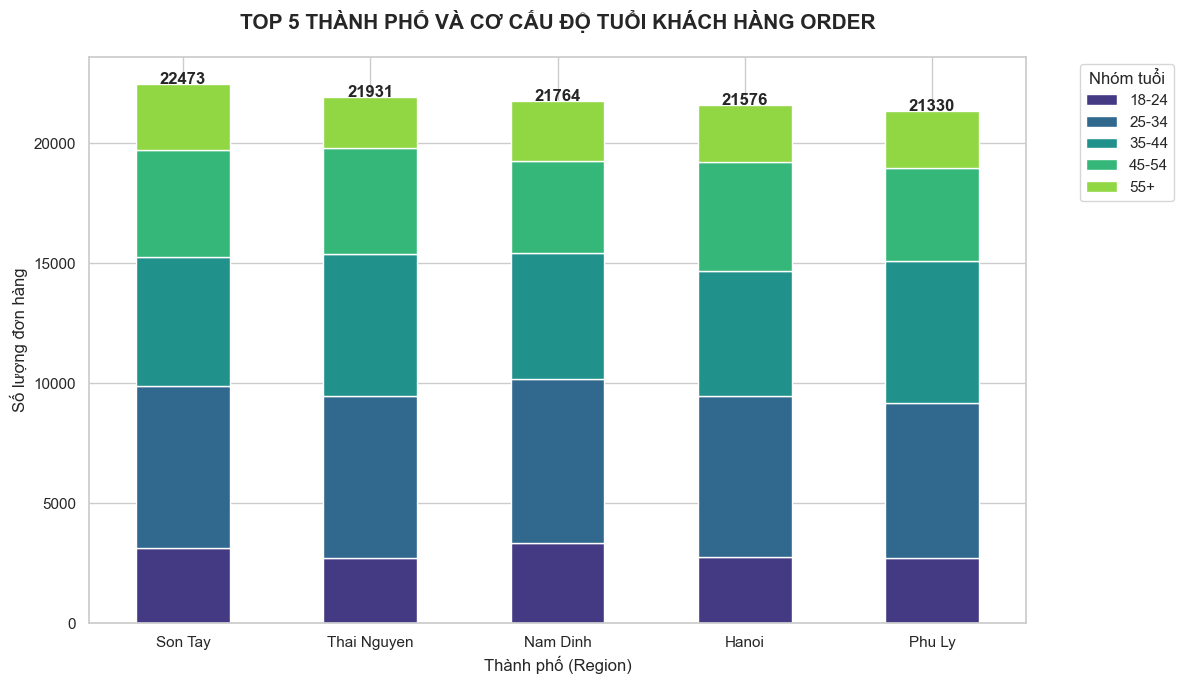

--- CHI TIẾT ĐƠN HÀNG THEO VÙNG VÀ ĐỘ TUỔI ---
| city        |   18-24 |   25-34 |   35-44 |   45-54 |   55+ |
|:------------|--------:|--------:|--------:|--------:|------:|
| Son Tay     |    3109 |    6763 |    5385 |    4455 |  2761 |
| Thai Nguyen |    2700 |    6755 |    5940 |    4409 |  2127 |
| Nam Dinh    |    3342 |    6815 |    5278 |    3813 |  2516 |
| Hanoi       |    2770 |    6690 |    5190 |    4560 |  2366 |
| Phu Ly      |    2707 |    6474 |    5919 |    3879 |  2351 |


In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Nối 2 bảng để lấy cả City và Age_Group
df_merged = df_orders.merge(df_customers[['customer_id', 'city', 'age_group']], on='customer_id', how='left')

# 2. Tìm Top 5 thành phố có lượng đơn hàng nhiều nhất (để lọc dữ liệu)
top_5_cities = df_merged['city'].value_counts().head(5).index.tolist()

# 3. Lọc dữ liệu chỉ lấy Top 5 thành phố này
df_top5 = df_merged[df_merged['city'].isin(top_5_cities)].copy()

# 4. Gom nhóm theo City và Age_Group để đếm số đơn hàng
df_pivot = df_top5.groupby(['city', 'age_group']).size().unstack(fill_value=0)

# 5. Sắp xếp lại các thành phố theo tổng lượng đơn hàng giảm dần để biểu đồ đẹp hơn
df_pivot['total'] = df_pivot.sum(axis=1)
df_pivot = df_pivot.sort_values(by='total', ascending=False).drop(columns='total')

# 6. Vẽ biểu đồ cột chồng (Stacked Bar Chart)
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# Vẽ bằng pandas plot cho nhanh và chuẩn với dạng pivot
ax = df_pivot.plot(kind='bar', stacked=True, figsize=(12, 7), 
                   color=sns.color_palette("viridis", len(df_pivot.columns)))

# 7. Trang trí
plt.title('TOP 5 THÀNH PHỐ VÀ CƠ CẤU ĐỘ TUỔI KHÁCH HÀNG ORDER', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Thành phố (Region)', fontsize=12)
plt.ylabel('Số lượng đơn hàng', fontsize=12)
plt.xticks(rotation=0) # Để tên thành phố nằm ngang cho dễ đọc

# Hiển thị chú thích nhóm tuổi
plt.legend(title='Nhóm tuổi', bbox_to_anchor=(1.05, 1), loc='upper left')

# Thêm con số tổng lên đầu mỗi cột cho dễ nhìn
totals = df_pivot.sum(axis=1).values
for i, total in enumerate(totals):
    plt.text(i, total + 0.5, f'{int(total)}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# In bảng pivot ra để ông kiểm tra số liệu
print("--- CHI TIẾT ĐƠN HÀNG THEO VÙNG VÀ ĐỘ TUỔI ---")
print(df_pivot.to_markdown())